# 2.4 指数型分布族 (The Exponential Family)
本ノートブックでは、ベルヌーイ分布、多項分布、ガウス分布、ポアソン分布、ガンマ分布などを共通の統一的な枠組みで包括する**指数型分布族 (The Exponential Family)** の理論的構造と性質を学びます。

### 本ノートブックの構成:
1. **指数型分布族の標準形 (Canonical Form)**: 自然母数、十分統計量、対数分配関数
2. **対数分配関数の微分とモーメントの導出**: 期待値と共分散の美しい双対関係
3. **共役事前分布の統一的導出**: 指数型分布族に対する普遍的な事後分布更新
4. **無情報事前分布とジェフリーズの事前分布 (Jeffreys Prior)**: 尺度不変性と変数変換不変性

## 2.4.1 指数型分布族の標準形

パラメータ $\boldsymbol{\eta}$ を持つ確率変数 $\mathbf{x}$ の分布が以下の形で表されるとき、**指数型分布族**に属すると言います。

$$ p(\mathbf{x} | \boldsymbol{\eta}) = h(\mathbf{x}) g(\boldsymbol{\eta}) \exp \{ \boldsymbol{\eta}^T \mathbf{u}(\mathbf{x}) \} $$

- $\boldsymbol{\eta}$: 自然母数 (natural parameters)
- $\mathbf{u}(\mathbf{x})$: 十分統計量 (sufficient statistics)
- $g(\boldsymbol{\eta})$: 分配関数の逆数

## 2.4.2 対数分配関数によるモーメントの導出

規格化条件の両辺を $\boldsymbol{\eta}$ について微分することでモーメント関係式が得られます。
$$ -\nabla_{\boldsymbol{\eta}} \ln g(\boldsymbol{\eta}) = \mathbb{E}[\mathbf{u}(\mathbf{x})] $$
$$ -\nabla_{\boldsymbol{\eta}}\nabla_{\boldsymbol{\eta}} \ln g(\boldsymbol{\eta}) = \mathrm{cov}[\mathbf{u}(\mathbf{x})] $$

Gradient -d ln g / d eta1: 2.5000 (E[x] = 2.5)
Gradient -d ln g / d eta2: 7.6900 (E[x^2] = 7.6899999999999995)
Plot saved to: result/fig2_exponential_family_moments.png


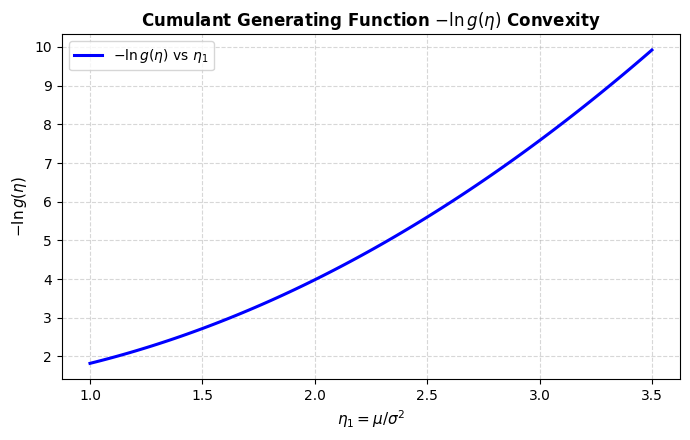

In [1]:
# ガウス分布における対数分配関数の微分によるモーメント導出の数値検証
import sys, os
sys.path.append(os.path.abspath('../'))
os.makedirs("result", exist_ok=True)
from common.plot_utils import save_plot, setup_style
setup_style()

import numpy as np
import matplotlib.pyplot as plt

mu_true = 2.5
sigma_true = 1.2
var_true = sigma_true ** 2

eta1 = mu_true / var_true
eta2 = -1.0 / (2.0 * var_true)
eta = np.array([eta1, eta2])

def neg_log_g(e):
    return - (e[0]**2) / (4.0 * e[1]) - 0.5 * np.log(-2.0 * e[1]) + 0.5 * np.log(2.0 * np.pi)

# 数値微分
eps = 1e-5
grad = np.zeros(2)
for i in range(2):
    e_plus = eta.copy(); e_plus[i] += eps
    e_minus = eta.copy(); e_minus[i] -= eps
    grad[i] = (neg_log_g(e_plus) - neg_log_g(e_minus)) / (2.0 * eps)

print(f"Gradient -d ln g / d eta1: {grad[0]:.4f} (E[x] = {mu_true})")
print(f"Gradient -d ln g / d eta2: {grad[1]:.4f} (E[x^2] = {mu_true**2 + var_true})")

eta1_vals = np.linspace(1.0, 3.5, 100)
energies = [neg_log_g([e1, eta2]) for e1 in eta1_vals]
fig = plt.figure(figsize=(7, 4.5))
plt.plot(eta1_vals, energies, 'b-', lw=2.2, label=r'$-\ln g(\eta)$ vs $\eta_1$')
plt.title(r'Cumulant Generating Function $-\ln g(\eta)$ Convexity', fontsize=12, fontweight='bold')
plt.xlabel(r'$\eta_1 = \mu / \sigma^2$', fontsize=11)
plt.ylabel(r'$-\ln g(\eta)$', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
save_plot(fig, "result", "fig2_exponential_family_moments.png")
plt.show()

## 2.4.3 無情報事前分布とジェフリーズの事前分布 (Jeffreys Prior)

フィッシャー情報量 $I(	heta) = -\mathbb{E}\left[\frac{\partial^2 \ln p}{\partial 	heta^2}\right]$ を用いて、変数変換に対して不変な客観的事前分布を定めます。
$$ p(	heta) \propto \sqrt{\det I(	heta)} $$

Plot saved to: result/fig2_jeffreys_prior.png


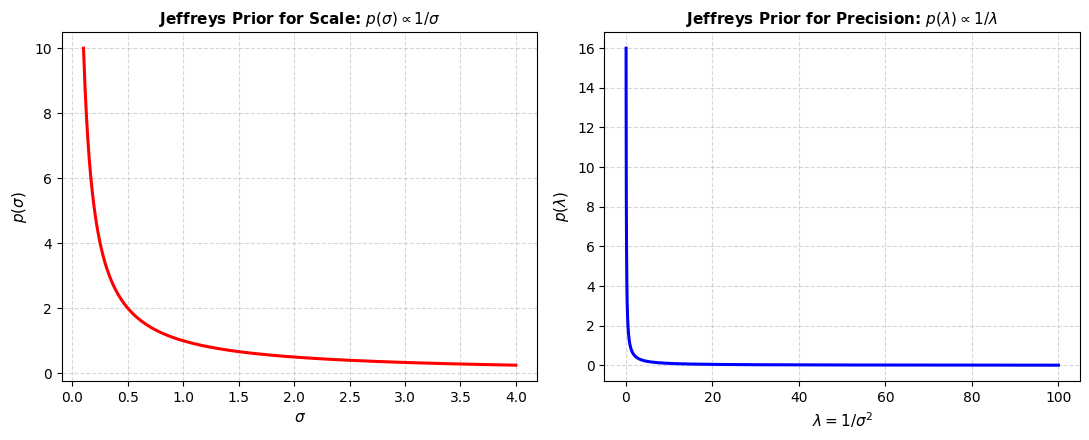

In [2]:
# ジェフリーズ事前分布の変数変換不変性の可視化
sigma_vals = np.linspace(0.1, 4.0, 300)
prior_sigma = 1.0 / sigma_vals

lam_vals = 1.0 / (sigma_vals ** 2)
prior_lam = 1.0 / lam_vals

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(sigma_vals, prior_sigma, 'r-', lw=2.2)
ax1.set_title(r'Jeffreys Prior for Scale: $p(\sigma) \propto 1/\sigma$', fontsize=11, fontweight='bold')
ax1.set_xlabel(r'$\sigma$', fontsize=11)
ax1.set_ylabel(r'$p(\sigma)$', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(lam_vals, prior_lam, 'b-', lw=2.2)
ax2.set_title(r'Jeffreys Prior for Precision: $p(\lambda) \propto 1/\lambda$', fontsize=11, fontweight='bold')
ax2.set_xlabel(r'$\lambda = 1/\sigma^2$', fontsize=11)
ax2.set_ylabel(r'$p(\lambda)$', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
save_plot(fig, "result", "fig2_jeffreys_prior.png")
plt.show()

## まとめ
1. 指数型分布族は十分統計量を通じたデータ要約と、分配関数の微分によるモーメント導出という普遍的な枠組みを提供する。
2. 指数型分布族に対する共役事前分布も普遍的に定義でき、ベイズ更新はハイパーパラメータの加算として定式化される。
3. ジェフリーズの事前分布は幾何学的な不変性を満たす客観的ベイズ事前分布の標準である。